Shape: (76, 3)
    &esc                  print a backslash  Unnamed: 2
0   &esc   line break; cequivalent to '.br'         NaN
1  &esc!          ignore rest of input line         NaN
2  &esc"  begin a comment until end of line         NaN
3  &esc#    comment character within a line         NaN
4  &esc$   refer to nth argument in a macro         NaN
Index(['&esc', 'print a backslash', 'Unnamed: 2'], dtype='str')
Text column: &esc
TF-IDF shape: (76, 21)

Silhouette scores:
2 0.4636
3 0.4676
4 0.4941
5 0.5424
6 0.5695
7 0.5974
8 0.6116
9 0.6539
10 0.6822

Best K: 10

Cluster sizes:
cluster
0    31
1     3
2    27
3     2
4     2
5     3
6     2
7     2
8     2
9     2
Name: count, dtype: int64

TOP WORDS PER CLUSTER

Cluster 0:
esc, xx, escz, escl, esca, escb, escc, escd, esce, escf, esch, escm, escx xx, escz xx, escn xx

Cluster 1:
escn, escn xx, xx, escx xx, escx, esca, escb, escc, escd, esce, escf, esch, escl, escm, escz xx

Cluster 2:
xx, escs, escv, escc, esco, escd, escl, esch, escz

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5014/3507485821.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


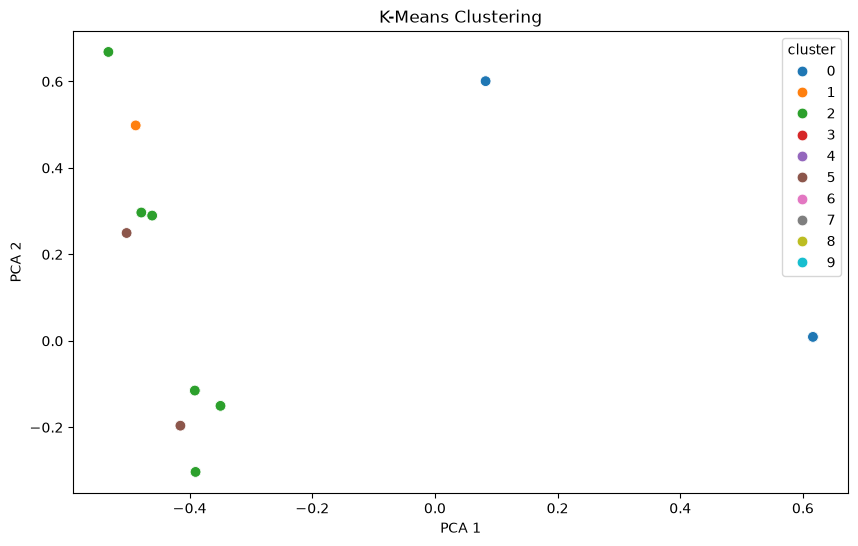

,&esc,clean_text,cluster
0,&esc,esc,0
1,&esc!,esc,0
2,"&esc""",esc,0
3,&esc#,esc,0
4,&esc$,esc,0
5,&esc$*,esc,0
6,&esc$0,esc,0
7,&esc$@,esc,0
8,&esc$^,esc,0
9,&esc%,esc,0



Saved: roff-escapes-kmeans-results.csv


In [1]:
# ============================================================
# NLP + K-MEANS | roff-escapes.csv
# ============================================================

# If needed:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# 1. LOAD DATA
df = pd.read_csv("roff-escapes.csv")

print("Shape:", df.shape)
print(df.head())
print(df.columns)


# 2. SELECT TEXT COLUMN
# Change this if your text column has a different name
text_col = df.select_dtypes(include="object").columns[0]

print("Text column:", text_col)


# 3. CLEAN DATA
df = df.dropna(subset=[text_col]).copy()
df[text_col] = df[text_col].astype(str)


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.split()
    words = [
        w for w in words
        if w not in ENGLISH_STOP_WORDS
    ]

    return " ".join(words)


df["clean_text"] = df[text_col].apply(clean_text)


# 4. TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)


# 5. FIND BEST K
scores = {}

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    scores[k] = silhouette_score(X, labels)


print("\nSilhouette scores:")
for k, score in scores.items():
    print(k, round(score, 4))


best_k = max(scores, key=scores.get)

print("\nBest K:", best_k)


# 6. K-MEANS
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)


# 7. CLUSTER SIZE
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())


# 8. TOP WORDS IN EACH CLUSTER
terms = tfidf.get_feature_names_out()

print("\nTOP WORDS PER CLUSTER")

for cluster in range(best_k):

    indexes = kmeans.cluster_centers_[cluster].argsort()[::-1][:15]

    words = [terms[i] for i in indexes]

    print(f"\nCluster {cluster}:")
    print(", ".join(words))


# 9. PCA VISUALISATION
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["cluster"],
    palette="tab10",
    s=60
)

plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# 10. DISPLAY RESULTS
display(
    df[[text_col, "clean_text", "cluster"]].head(20)
)


# 11. SAVE RESULTS
df.to_csv(
    "roff-escapes-kmeans-results.csv",
    index=False
)

print("\nSaved: roff-escapes-kmeans-results.csv")